In [2]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 1
NUM_EPOCHS_PRETRAIN = 2
NUM_EPOCHS_GAN = 2
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "../archive/Dataset-2/DIV2K_train_HR"
TEST_DIR = "../archive/Dataset-2/DIV2K_valid_HR"

# From The Paper

```
Instead of relying on pixel-wise losses we build on the
ideas of Gatys et al. [19], Bruna et al. [5] and Johnson et
al. [33] and use a loss function that is closer to perceptual
similarity. We define the VGG loss based on the ReLU
activation layers of the pre-trained 19 layer VGG network
described in Simonyan and Zisserman [49]. With ij we
indicate the feature map obtained by the j-th convolution
(after activation) before the i-th maxpooling layer within the
VGG19 network, which we consider given. We then define
the VGG loss as the euclidean distance between the feature
representations of a reconstructed image GG
(ILR) and the reference image IHR:
```

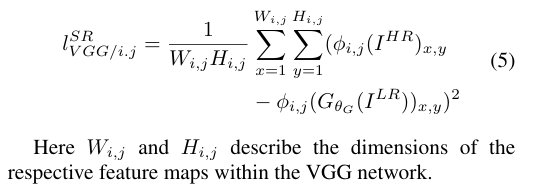

### About Content Loss

- Euclidean distance between the HR reference image and the generated image
- Both images are passed through the VGG network to extract features, in fact we are finding the euclidean distance between the feature maps of the two images.

### Why do we use VGG here?
- a coefficient which is the feature map obtained from the j-th convolution (after activation) before the i-th maxpooling layer within the VGG19 network

### Code Explanation

```python
vgg_model = vgg19(weights="DEFAULT").features[:36].to(device).eval()
```
- First we load a pretrained VGG19 using ImageNet weights.
- We only take the first 36 layers of the VGG19 model, which is the convolutional layers and activation layers.
- We set the model to evaluation mode using `.eval()`, which is important for inference.
- What happened during eval?
    - Dropout layers are turned off. 
        - Dropout layers are used during training to prevent overfitting by randomly setting some activations to zero.
    - Batch normalization layers use running statistics instead of batch statistics.

```
No Batch-wise Calculations: The BN layer stops calculating the mean and variance from the current input mini-batch.
Using Accumulated Running Statistics: Instead of calculating statistics from the current batch, it uses the running_mean and running_var that it accumulated and updated throughout the entire training process.
So, during evaluation, the normalization is performed using these global, more stable statistics: x_hat = (x - running_mean) / sqrt(running_var + ε).
No Updates to Running Statistics: The running_mean and running_var are not updated during evaluation. They remain fixed at the values learned during training.
```

In [ ]:
# loss.py
import torch
from torch import nn
from torchvision.models import vgg19

class VGGContentLoss(nn.Module):
    """
    Calculates the content loss in the VGG19 feature space.
    The paper uses the features from the layer before the 5th max-pooling layer (VGG54).
    In PyTorch's VGG19 implementation, this corresponds to `features[35]`.
    """
    def __init__(self, device):
        super(VGGContentLoss, self).__init__()
        vgg_model = vgg19(weights="DEFAULT").features[:36].to(device).eval()
        for param in vgg_model.parameters():
            param.requires_grad = False # why we turn off gradient? we don't want to find gradient during back propogation, we just want to use the model to extract features
        self.vgg_model = vgg_model # when call .vgg_model it will return the vgg model, this model is loaded with features[:36] which is the first 36 layers of vgg19 and turn off the gradient
        self.loss = nn.MSELoss() # paper says euclidean distance, so mse shoud be appropriate

    def forward(self, generated, target):
        gen_features = self.vgg_model(generated) # feed the generated image here to get the featurs map 
        target_features = self.vgg_model(target) # feed the target image here to get the features map
        return self.loss(gen_features, target_features) # find the difference between the two features map